In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max

In [10]:
# Helpers

def load_ground_truth(xml_path):
    """Parse Pascal VOC XML, return list of (xmin, ymin, xmax, ymax)."""
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall('object'):
        bb = obj.find('bndbox')
        boxes.append((
            int(bb.find('xmin').text), int(bb.find('ymin').text),
            int(bb.find('xmax').text), int(bb.find('ymax').text),
        ))
    return boxes


def apply_circular_mask(template):
    """Zero out pixels outside the largest inscribed circle of the template."""
    h, w = template.shape
    Y, X = np.ogrid[:h, :w]
    mask = (X - w/2)**2 + (Y - h/2)**2 <= min(w/2, h/2)**2
    out = template.astype(np.float32, copy=True)
    out[~mask] = 0.0
    return out


def rotate_template(template, angle):
    """Rotate template by angle degrees, expanding canvas so content is not cropped."""
    h, w = template.shape[:2]
    cx, cy = w / 2, h / 2
    M = cv.getRotationMatrix2D((cx, cy), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)
    M[0, 2] += new_w / 2 - cx
    M[1, 2] += new_h / 2 - cy
    return cv.warpAffine(template, M, (new_w, new_h))

def iou_xyxy(a, b):
    """IoU between two (xmin, ymin, xmax, ymax) boxes."""
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter / union if union > 0 else 0


def evaluate(detections_rowcol, ground_truth_xyxy, iou_threshold=0.5):
    """
    Compare detections (row, col, h, w) against ground truth (xmin, ymin, xmax, ymax).
    Returns dict with TP, FP, FN, precision, recall, F1, and per-GT IoU.
    """
    # Convert detections to (xmin, ymin, xmax, ymax)
    det_xyxy = [(x, y, x+w, y+h) for (y, x, h, w) in detections_rowcol]

    matched_gt = set()
    tp = 0
    per_det_iou = []

    for det in det_xyxy:
        best_iou, best_idx = 0.0, -1
        for i, gt in enumerate(ground_truth_xyxy):
            if i in matched_gt:
                continue
            iou = iou_xyxy(det, gt)
            if iou > best_iou:
                best_iou, best_idx = iou, i
        per_det_iou.append(best_iou)
        if best_iou >= iou_threshold:
            tp += 1
            matched_gt.add(best_idx)

    fp = len(det_xyxy) - tp
    fn = len(ground_truth_xyxy) - tp
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0.0

    return dict(TP=tp, FP=fp, FN=fn,
                precision=prec, recall=rec, f1=f1,
                per_det_iou=per_det_iou)


def parabolic_subpixel(corr_map, row, col):
    """
    Fit a 1-D parabola through 3 points in each axis to find the sub-pixel
    maximum of corr_map near (row, col).

    For a maximum at x0 with neighbours f(-1), f(0), f(+1):
        offset = 0.5 * (f(-1) - f(+1)) / (f(-1) - 2*f(0) + f(+1))

    Returns (row_sub, col_sub) as floats.
    """
    H, W = corr_map.shape
    row_sub = float(row)
    col_sub = float(col)

    if 0 < row < H - 1:
        fy_m, fy_0, fy_p = corr_map[row-1, col], corr_map[row, col], corr_map[row+1, col]
        d = fy_m - 2*fy_0 + fy_p
        if abs(d) > 1e-10:
            row_sub = row + 0.5 * (fy_m - fy_p) / d

    if 0 < col < W - 1:
        fx_m, fx_0, fx_p = corr_map[row, col-1], corr_map[row, col], corr_map[row, col+1]
        d = fx_m - 2*fx_0 + fx_p
        if abs(d) > 1e-10:
            col_sub = col + 0.5 * (fx_m - fx_p) / d

    return row_sub, col_sub


def draw_detections(image, detections, ground_truth=None,
                    figsize=(12, 12), linewidth=2, save_path="output.png"):
    """
    Draw detections (red) and optionally ground truth boxes (green).
    detections : list of (row, col, h, w)
    ground_truth: list of (xmin, ymin, xmax, ymax)
    """
    img = image.copy().astype(np.float32)
    if img.max() > 1.0:
        img /= 255.0
    H, W = img.shape[:2]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)

    for (y, x, h_t, w_t) in detections:
        x0 = max(0, min(int(round(x)), W-1))
        y0 = max(0, min(int(round(y)), H-1))
        ax.add_patch(Rectangle((x0, y0), min(w_t, W-x0), min(h_t, H-y0),
                                linewidth=linewidth, edgecolor='red', facecolor='none'))

    if ground_truth:
        for (xmin, ymin, xmax, ymax) in ground_truth:
            ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                    linewidth=linewidth, edgecolor='lime', facecolor='none',
                                    linestyle='--'))

    # Legend
    from matplotlib.lines import Line2D
    legend = [Line2D([0], [0], color='red',  lw=2, label='Detected'),
              Line2D([0], [0], color='lime', lw=2, linestyle='--', label='Ground truth')]
    ax.legend(handles=legend, loc='upper right', fontsize=10)

    ax.set_axis_off()
    plt.tight_layout()
    # plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()

In [11]:
img = cv.imread('coins-1/20210324_151227.jpg', 0)
img_t = cv.imread('cointemp.jpg', 0)
gt    = load_ground_truth('coins-1/20210324_151227.xml')

H, W = img.shape

img_zm = img.astype(np.float32) - np.mean(img)
img_f  = np.fft.fft2(img_zm)

In [12]:
scales        = np.linspace(0.25, 1.25, 20)
angles        = np.arange(0, 360, 30)
THRESHOLD_ABS = 0.65
IOU_THRESHOLD = 0.3

In [ ]:
confirmed = []  # (row, col, h, w, score)

def center_inside_confirmed(row, col, h_t, w_t):
    """Check if the CENTER of this detection falls inside any confirmed box."""
    cy = row + h_t // 2
    cx = col + w_t // 2
    for (ky, kx, kh, kw, _) in confirmed:
        if ky <= cy < ky + kh and kx <= cx < kx + kw:
            return True
    return False

img_float = img.astype(np.float32)

for scale in sorted(scales, reverse=True):
    new_h = max(1, int(img_t.shape[0] * scale))
    new_w = max(1, int(img_t.shape[1] * scale))
    tmpl_scaled = apply_circular_mask(cv.resize(img_t, (new_w, new_h)))
    h_t, w_t = tmpl_scaled.shape  # unrotated template size — defines our coordinate system

    if h_t > H or w_t > W:
        continue

    # Output map aligned to unrotated-template coordinates.
    # Position (r, c) here means "unrotated template top-left at image (r, c)".
    H_out = H - h_t + 1
    W_out = W - w_t + 1
    best_corr = np.full((H_out, W_out), -np.inf, dtype=np.float32)

    for angle in angles:
        tmpl = rotate_template(tmpl_scaled, angle)
        th_r, tw_r = tmpl.shape  # rotated size — larger than (h_t, w_t)
        if th_r > H or tw_r > W:
            continue

        corr = cv.matchTemplate(img_float, tmpl, cv.TM_CCOEFF_NORMED)
        corr = -corr
        # corr[r, c] = score when rotated template's top-left is at image (r, c).
        # The original object's center is at (r + th_r//2, c + tw_r//2).
        # In unrotated coords, top-left = center - (h_t//2, w_t//2)
        #   => unrotated row = r + (th_r - h_t) // 2
        #   => unrotated col = c + (tw_r - w_t) // 2
        row_off = (th_r - h_t) // 2
        col_off = (tw_r - w_t) // 2

        # Destination region in best_corr
        r0 = row_off
        c0 = col_off
        r1 = r0 + corr.shape[0]
        c1 = c0 + corr.shape[1]

        # Clip to output map bounds
        r0c, c0c = max(0, r0), max(0, c0)
        r1c, c1c = min(H_out, r1), min(W_out, c1)

        # Corresponding source region in corr
        cr0 = r0c - r0
        cc0 = c0c - c0
        cr1 = cr0 + (r1c - r0c)
        cc1 = cc0 + (c1c - c0c)

        if r1c > r0c and c1c > c0c:
            best_corr[r0c:r1c, c0c:c1c] = np.maximum(
                best_corr[r0c:r1c, c0c:c1c],
                corr[cr0:cr1, cc0:cc1]
            )

    # Mask out -inf padding before peak detection
    valid = best_corr > -np.inf
    best_corr[~valid] = 0.0

    min_dist = max(10, min(h_t, w_t) // 3)
    peaks = peak_local_max(best_corr, min_distance=min_dist, threshold_abs=0.5)

    for (row, col) in sorted(peaks, key=lambda p: best_corr[p[0], p[1]], reverse=True):
        if not center_inside_confirmed(row, col, h_t, w_t):
            confirmed.append((row, col, h_t, w_t, best_corr[row, col]))

In [18]:
# plt.figure(figsize=(8,8))
# plt.imshow(inverted, cmap='viridis')
# plt.colorbar()
# plt.title("Correlation Map")
# plt.show()


Detected: 7   Ground truth: 7
TP=7  FP=0  FN=0
Precision=1.00  Recall=1.00  F1=1.00

Per-detection best IoU: [np.float64(0.51), np.float64(0.41), np.float64(0.4), np.float64(0.48), np.float64(0.5), np.float64(0.43), np.float64(0.56)]


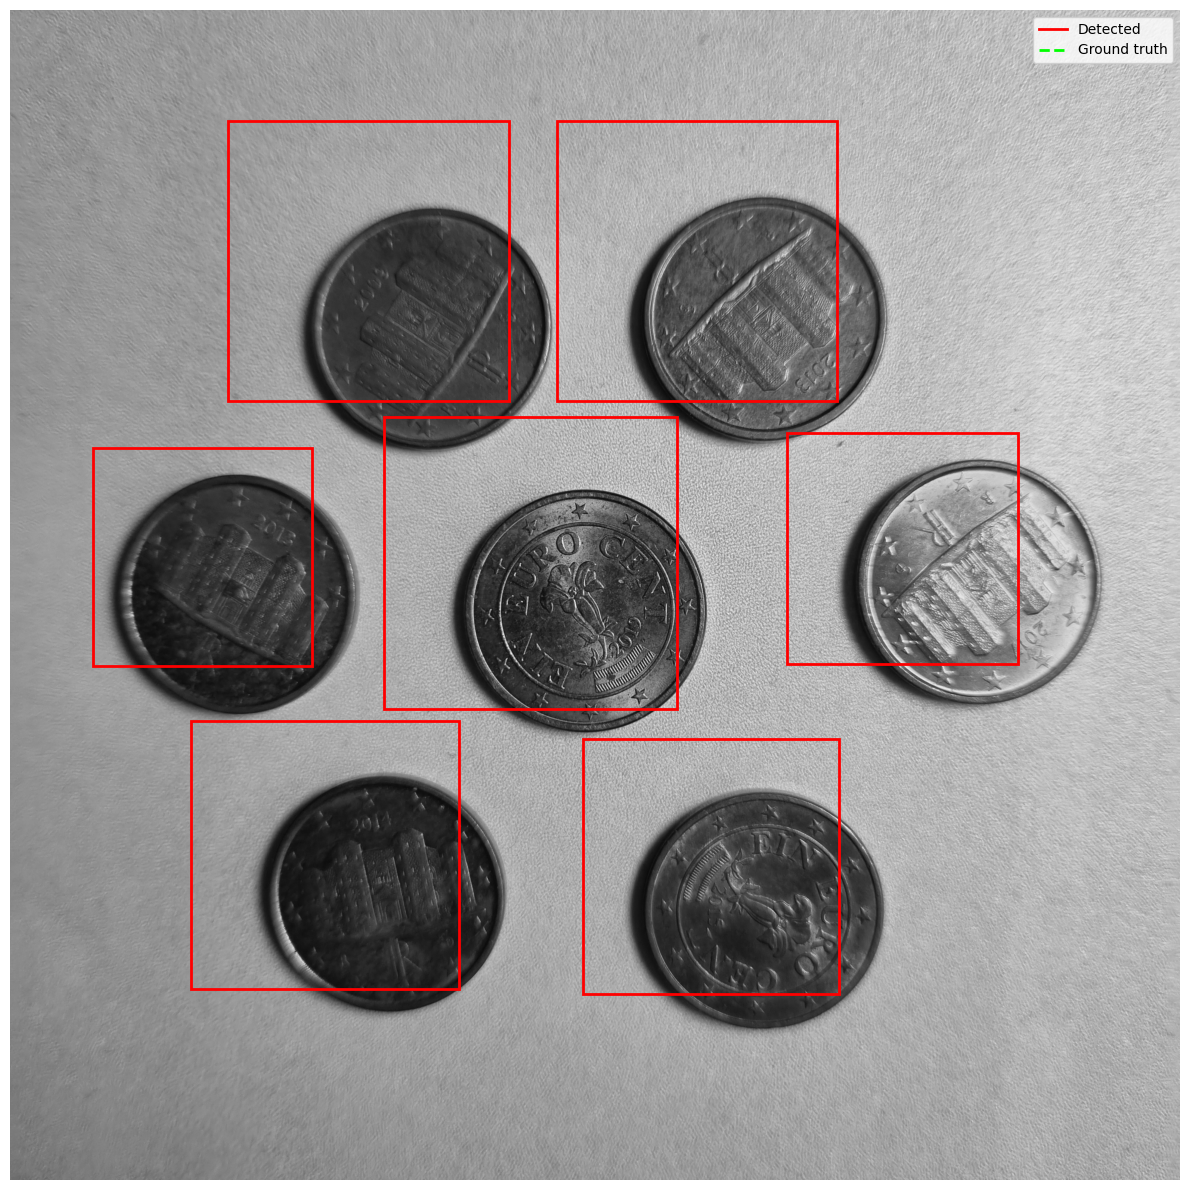

In [21]:
final_detections = confirmed

# Evaluate against ground truth
det_boxes = [(d[0], d[1], d[2], d[3]) for d in final_detections]
metrics   = evaluate(det_boxes, gt, IOU_THRESHOLD)

print(f"\nDetected: {len(final_detections)}   Ground truth: {len(gt)}")
print(f"TP={metrics['TP']}  FP={metrics['FP']}  FN={metrics['FN']}")
print(f"Precision={metrics['precision']:.2f}  Recall={metrics['recall']:.2f}  F1={metrics['f1']:.2f}")
print(f"\nPer-detection best IoU: {[round(v,2) for v in metrics['per_det_iou']]}")

# Draw
draw_detections(img, det_boxes, [])